# Q1. Using filter-based feature selection with Information Gain (mutual information) on the Wine dataset,
The most discriminating features are:
- Flavanoids (0.667)
- Color_intensity (0.559)
- Proline (0.558)

The least discriminating features are:
- Magnesium (0.216)
- Nonflavanoid_phenols (0.128)
- Ash (0.056)

These scores indicate how informative each feature is about the wine class label.

Using 10-fold cross-validation with a 1-Nearest Neighbour classifier:
	•	Using only the three most discriminating features, the mean classification accuracy is 0.95.
	•	Using only the three least discriminating features, the mean classification accuracy is 0.566.

These results demonstrate that features with higher Information Gain significantly improve classification performance and provide strong class separation, leading to near-optimal accuracy, while the least informative features contribute little discriminatory power and result in substantially lower performance.

In [6]:
import pandas as pd
from google.colab import files

# 1) Upload the CSV file (choose your Wine CSV)
uploaded = files.upload()



Saving wine.csv to wine (1).csv


In [7]:
import pandas as pd
from sklearn.feature_selection import chi2
from sklearn.feature_selection import mutual_info_classif
from sklearn import preprocessing

In [8]:
wine_DF = pd.read_csv('wine.csv')
print(wine_DF.shape)
wine_DF.head()

(178, 14)


,Alcohol,Malic_acid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,OD280/OD315_of_diluted_wines,Proline,class
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,Type1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,Type1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,Type1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,Type1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,Type1


In [18]:
wine_DF = pd.read_csv('wine.csv') # Reload the DataFrame
y = wine_DF.pop('class').values
X = wine_DF.values
wine_DF.shape
feature_names = wine_DF.columns

In [19]:
i_scores = mutual_info_classif(X,y)

In [20]:
FS_DF = pd.DataFrame(i_scores,index = wine_DF.columns, columns =['I-Gain'])
FS_DF.sort_values(by=['I-Gain'],ascending=False,inplace=True)
FS_DF

,I-Gain
Flavanoids,0.667151
Color_intensity,0.559001
Proline,0.558083
OD280/OD315_of_diluted_wines,0.507898
Alcohol,0.466463
Hue,0.451234
Total_phenols,0.410656
Proanthocyanins,0.300046
Malic_acid,0.280156
Alcalinity_of_ash,0.239077


In [21]:
bottom3_DF = wine_DF[FS_DF.index[-3:]]
X_bottom3 = bottom3_DF.values

In [22]:
from sklearn.neighbors import KNeighborsClassifier
kNN = KNeighborsClassifier(n_neighbors=1)

In [23]:
bottom3_DF

,Magnesium,Nonflavanoid_phenols,Ash
0,127,0.28,2.43
1,100,0.26,2.14
2,101,0.30,2.67
3,113,0.24,2.50
4,118,0.39,2.87
...,...,...,...
173,95,0.52,2.45
174,102,0.43,2.48
175,120,0.43,2.26
176,120,0.53,2.37


In [26]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1) top/bottom 3 feature names from IG table
top3 = FS_DF.index[:3].tolist()
bottom3 = FS_DF.index[-3:].tolist()

# 2) select those columns from the DATAFRAME (not from numpy X)
X_top3 = wine_DF[top3].values
X_bottom3 = wine_DF[bottom3].values

# 3) 1-NN with scaling
model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=1))
])

# 4) 10-fold CV accuracy
scores_top3 = cross_val_score(model, X_top3, y, cv=10)
scores_bottom3 = cross_val_score(model, X_bottom3, y, cv=10)

print("Top 3 features -> Mean accuracy:", round(scores_top3.mean(), 3))
print("Bottom 3 features -> Mean accuracy:", round(scores_bottom3.mean(), 3))

Top 3 features -> Mean accuracy: 0.95
Bottom 3 features -> Mean accuracy: 0.566


# Q2. Using wrapper-based feature selection with a 3-Nearest Neighbour classifier and 10-fold cross-validation, both forward sequential search and backward elimination selected largely overlapping feature subsets. The common features identified by both strategies were:

**Alcalinity_of_ash, Alcohol, Color_intensity, Magnesium, and Proline.**

These features appear to be consistently informative for classification, as they were independently selected by two different wrapper search procedures.

Although Magnesium had low Information Gain, it was selected by the wrapper method because wrapper-based selection evaluates feature subsets jointly rather than individually. While Magnesium may not be strongly discriminative on its own, it likely improves class separation when combined with other features, particularly under a distance-based classifier such as kNN.

In [52]:
import pandas as pd

wine_DF = pd.read_csv("wine.csv")   # знову з class
X_df = wine_DF.drop(columns=["class"])
y = wine_DF["class"].values
feat_names = X_df.columns.tolist()

In [53]:
wine_DF.columns

Index(['Alcohol', 'Malic_acid', 'Ash', 'Alcalinity_of_ash', 'Magnesium',
       'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols',
       'Proanthocyanins', 'Color_intensity', 'Hue',
       'OD280/OD315_of_diluted_wines', 'Proline', 'class'],
      dtype='object')

In [56]:
# If needed (Colab):
# !pip -q install mlxtend

import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

# Reload wine_DF for this cell to ensure 'class' column is present
wine_DF_local = pd.read_csv('wine.csv')

# 1) Split into X (DataFrame with column names) and y
y = wine_DF_local["class"].values
X_df = wine_DF_local.drop(columns=["class"])   # keep feature names!

# 2) Scale features (important for kNN)
schaler = MinMaxScaler()
X_scaled = schaler.fit_transform(X_df)    # numpy is fine here...

# 3) Wrapper feature selection with 3-NN
knn3 = KNeighborsClassifier(n_neighbors=3)

# Forward sequential search
sfs_fwd = SFS(knn3,
              k_features=7,        # keep as in tutorial unless your task says otherwise
              forward=True,
              floating=False,
              scoring="accuracy",
              cv=10,
              n_jobs=-1)

# Backward elimination search
sfs_bwd = SFS(knn3,
              k_features=7,
              forward=False,
              floating=False,
              scoring="accuracy",
              cv=10,
              n_jobs=-1)

# Fit SFS without passing feature_names to avoid TypeError
sfs_fwd = sfs_fwd.fit(X_scaled, y)
sfs_bwd = sfs_bwd.fit(X_scaled, y)

# Retrieve feature names using the selected indices
fwd_feats = set(X_df.columns[list(sfs_fwd.k_feature_idx_)])
bwd_feats = set(X_df.columns[list(sfs_bwd.k_feature_idx_)])
common = sorted(fwd_feats & bwd_feats)

print("Forward:", sorted(fwd_feats))
print("Backward:", sorted(bwd_feats))
print("Common:", common)

Forward: ['Alcalinity_of_ash', 'Alcohol', 'Color_intensity', 'Flavanoids', 'Hue', 'Magnesium', 'Proline']
Backward: ['Alcalinity_of_ash', 'Alcohol', 'Color_intensity', 'Magnesium', 'Malic_acid', 'OD280/OD315_of_diluted_wines', 'Proline']
Common: ['Alcalinity_of_ash', 'Alcohol', 'Color_intensity', 'Magnesium', 'Proline']


# Q3.1. Forward Sequential Search (All Data)

Using all 2310 samples, forward sequential search with a 3-Nearest Neighbour classifier selected the following five features:

	•	REGION-CENTROID-ROW
	•	HEDGE-MEAN
	•	INTENSITY-MEAN
	•	SATURATION-MEAN
	•	HUE-MEAN


The 10-fold cross-validation accuracy of this selected subset was:

**Accuracy = 0.95**


(2310, 20)


,Class,REGION-CENTROID-COL,REGION-CENTROID-ROW,REGION-PIXEL-COUNT,SHORT-LINE-DENSITY-5,SHORT-LINE-DENSITY-2,VEDGE-MEAN,VEDGE-SD,HEDGE-MEAN,HEDGE-SD,INTENSITY-MEAN,RAWRED-MEAN,RAWBLUE-MEAN,RAWGREEN-MEAN,EXRED-MEAN,EXBLUE-MEAN,EXGREEN-MEAN,VALUE-MEAN,SATURATION-MEAN,HUE-MEAN
0,BRICKFACE,140.0,125.0,9,0.0,0.0,0.277778,0.062963,0.666667,0.311111,6.185185,7.333334,7.666666,3.555556,3.444444,4.444445,-7.888889,7.777778,0.545635,-1.121818
1,BRICKFACE,188.0,133.0,9,0.0,0.0,0.333333,0.266667,0.500000,0.077778,6.666666,8.333334,7.777778,3.888889,5.000000,3.333333,-8.333333,8.444445,0.538580,-0.924817
2,BRICKFACE,105.0,139.0,9,0.0,0.0,0.277778,0.107407,0.833333,0.522222,6.111111,7.555555,7.222222,3.555556,4.333334,3.333333,-7.666666,7.555555,0.532628,-0.965946
3,BRICKFACE,34.0,137.0,9,0.0,0.0,0.500000,0.166667,1.111111,0.474074,5.851852,7.777778,6.444445,3.333333,5.777778,1.777778,-7.555555,7.777778,0.573633,-0.744272
4,BRICKFACE,39.0,111.0,9,0.0,0.0,0.722222,0.374074,0.888889,0.429629,6.037037,7.000000,7.666666,3.444444,2.888889,4.888889,-7.777778,7.888889,0.562919,-1.175773


In [63]:
y = seg_data.pop('Class').values
X = seg_data.values
seg_scaler = preprocessing.MinMaxScaler().fit(X)
X_scaled = seg_scaler.transform(X)
print(X_scaled.shape)
feature_names = seg_data.columns

(2310, 19)


In [64]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

sfs_all = SFS(knn,
           k_features=5,
           forward=True,
           floating=False,
           verbose=0,
           scoring='accuracy',
           cv=0)

sfs_all = sfs_all.fit(X_scaled, y)
inds = sfs_all.k_feature_names_
[feature_names[int(x)] for x in inds]

['REGION-CENTROID-ROW',
 'HEDGE-MEAN',
 'INTENSITY-MEAN',
 'SATURATION-MEAN',
 'HUE-MEAN']

In [65]:
X_w_all = sfs_all.transform(X_scaled)
X_w_all.shape

(2310, 5)

In [66]:
from sklearn.model_selection import cross_val_score
acc_all = cross_val_score(knn, X_w_all, y, cv=10)
print("10x CV Accuracy Wrapper (All) features: {0:.2f}".format(acc_all.mean()))

10x CV Accuracy Wrapper (All) features: 0.95


# Q3.2. Using Only 1000 Data Points

Using only the first 1000 samples, the forward sequential search selected:

	•	REGION-CENTROID-ROW
	•	EXGREEN-MEAN
	•	VALUE-MEAN
	•	SATURATION-MEAN
	•	HUE-MEAN


The 10-fold cross-validation accuracy was:

**Accuracy = 0.963**

# Q3.3. Comparison

The selected **feature subsets are not identical**, although they share several common features (REGION-CENTROID-ROW, SATURATION-MEAN, HUE-MEAN).

**The accuracy is slightly higher when using only 1000 samples (0.963 vs 0.95).**

This indicates that wrapper-based feature selection is sensitive to the size of the dataset, and different sample sizes may lead to different selected feature subsets and slightly different performance estimates.

In [78]:
# --- FULL RESET FOR SEGMENTATION DATA ---

import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1) Load fresh
seg_data = pd.read_csv("segmentation-all.csv")
seg_data.columns = seg_data.columns.str.strip()

print("Shape:", seg_data.shape)

# 2) Define X and y (FIRST column is class)
y = seg_data.iloc[:, 0].values
X_df = seg_data.iloc[:, 1:]

print("X shape:", X_df.shape)
print("y length:", len(y))

# 3) Scale
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_df)

print("Scaled shape:", X_scaled.shape)

Shape: (2310, 20)
X shape: (2310, 19)
y length: 2310
Scaled shape: (2310, 19)


In [79]:
X_1000 = X_scaled[:1000]
y_1000 = y[:1000]

print(X_1000.shape)
print(len(y_1000))

(1000, 19)
1000


In [81]:
from sklearn.neighbors import KNeighborsClassifier
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

knn3 = KNeighborsClassifier(n_neighbors=3)

sfs_1000 = SFS(
    knn3,
    k_features=5,
    forward=True,
    floating=False,
    scoring='accuracy',
    cv=10,
    n_jobs=-1
)

sfs_1000 = sfs_1000.fit(X_1000, y_1000)

# selected feature names
selected_features_1000 = [feature_names[i] for i in sfs_1000.k_feature_idx_]
print("Selected 5 features (1000 samples):")
print(selected_features_1000)

Selected 5 features (1000 samples):
['REGION-CENTROID-ROW', 'EXGREEN-MEAN', 'VALUE-MEAN', 'SATURATION-MEAN', 'HUE-MEAN']


In [82]:
from sklearn.model_selection import cross_val_score

X_selected_1000 = sfs_1000.transform(X_1000)

acc_1000 = cross_val_score(knn3, X_selected_1000, y_1000, cv=10)
print("10-fold CV Accuracy (1000 samples):", round(acc_1000.mean(), 3))

10-fold CV Accuracy (1000 samples): 0.963


# Q4.1. Base-line Accuracy

Using the scaled original features and a k-Nearest Neighbour classifier (k = 5), the 10-fold cross-validation accuracy is:

**Baseline accuracy = 0.966**

This represents the reference performance of the classifier before applying PCA-based dimensionality reduction.

In [83]:
import pandas as pd

# завантажуємо
wine_df = pd.read_csv("wine.csv")

# прибираємо пробіли в назвах колонок (на всякий випадок)
wine_df.columns = wine_df.columns.str.strip()

print("Shape:", wine_df.shape)
print("Columns:", wine_df.columns.tolist())
wine_df.head()

Shape: (178, 14)
Columns: ['Alcohol', 'Malic_acid', 'Ash', 'Alcalinity_of_ash', 'Magnesium', 'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols', 'Proanthocyanins', 'Color_intensity', 'Hue', 'OD280/OD315_of_diluted_wines', 'Proline', 'class']


,Alcohol,Malic_acid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,OD280/OD315_of_diluted_wines,Proline,class
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,Type1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,Type1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,Type1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,Type1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,Type1


In [84]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
import numpy as np

# 1) target і features
y = wine_df["class"].values
X = wine_df.drop(columns=["class"]).values

# 2) pipeline: scaling + kNN
knn = KNeighborsClassifier(n_neighbors=5)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", knn)
])

# 3) 10-fold cross-validation
scores = cross_val_score(model, X, y, cv=10)

print("Baseline accuracy (scaled features):", round(scores.mean(), 3))

Baseline accuracy (scaled features): 0.966


# Q4.2. The first principal component explains approximately 36% of the total variance. The first 5 components explain about 80%, and the first 8 components explain over 92% of the variance. By 10 components, approximately 96% of the total variance is captured.

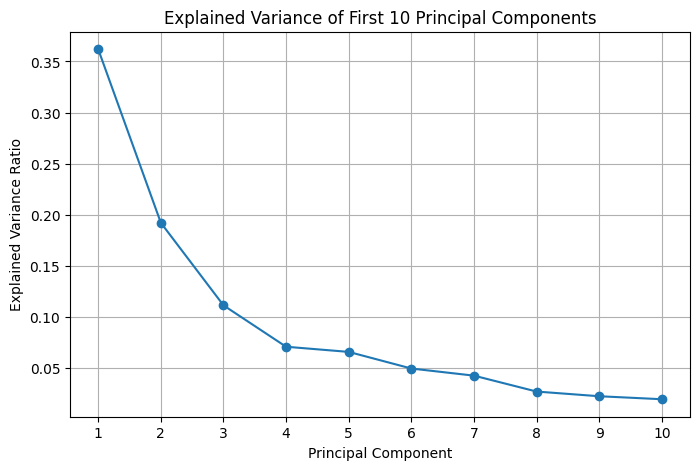

Cumulative variance:
[0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717]


In [85]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# 1) Scaling (важливо для PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2) PCA (беремо перші 10 компонент)
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

# 3) Explained variance ratio
explained_var = pca.explained_variance_ratio_

# 4) Plot
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), explained_var, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance of First 10 Principal Components")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

# додатково — cumulative variance (дуже корисно для наступного пункту)
print("Cumulative variance:")
print(np.cumsum(explained_var))

# Q4.3. The first **5 principal components explain approximately 80%** of the total variance. Additional components provide only marginal improvements in explained variance. Therefore, selecting 5 PCs offers a good balance between dimensionality reduction and information retention.

# Q4.4. Using 5 principal components, the 10-fold cross-validation accuracy of the k-NN classifier is: **Accuracy = 0.966 This is equal to the baseline** accuracy obtained using all scaled features, indicating that reducing the data to 5 PCs does not degrade classification performance.

In [86]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# pipeline: scaling → PCA(5) → kNN
model_pca5 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=5)),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

scores_pca5 = cross_val_score(model_pca5, X, y, cv=10)

print("Accuracy with 5 PCs:", round(scores_pca5.mean(), 3))

Accuracy with 5 PCs: 0.966


# Q4.5. When using only one principal component, the 10-fold cross-validation accuracy of the k-NN classifier is: **Accuracy = 0.838** taht is lower compared to both the baseline (0.966) and the 5-PC representation (0.966).

In [87]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

model_pca1 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=1)),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

scores_pca1 = cross_val_score(model_pca1, X, y, cv=10)

print("Accuracy with 1 PC:", round(scores_pca1.mean(), 3))

Accuracy with 1 PC: 0.838


# Q5.1. For 8 features, the total number of possible subsets is: **(c) 255**

2^8 = 256

However, the empty set is typically excluded in feature selection.

Therefore, the number of subsets evaluated in an exhaustive wrapper search is:

2^8 - 1 = 255


# Q5.2. Difference between Wrapper and Filter Methods

**Filter methods** evaluate features independently of any specific learning algorithm.
They rely on statistical measures such as correlation, mutual information, chi-square score, or variance.

Example:

	•	Selecting features based on Information Gain

	•	Removing low-variance features.

Filter methods are computationally efficient but do not consider interactions between features and the classifier.


**Wrapper methods**, in contrast, evaluate feature subsets by training and validating a specific model.
They search for the subset that maximizes predictive performance.

Example:

	•	Forward Sequential Search using k-NN

	•	Backward Elimination using cross-validation accuracy

Wrapper methods are more computationally expensive but often yield better performance because they consider feature interactions and model behavior.


# Q5.3. Intrinsic (Implicit) Feature Selection in Decision Trees


Decision trees perform intrinsic feature selection during training.
At each split, the algorithm selects the feature that maximizes an impurity reduction criterion (e.g., Gini index or Information Gain).


Features that are not useful for splitting are simply never selected, meaning the tree naturally ignores irrelevant features.


Thus, feature selection is embedded directly within the model training process.

# Q5.4. Permutation Importance

Permutation importance measures feature importance by **randomly shuffling the values of one feature** and observing the drop in model performance.

Procedure:

	1.	Train a model normally

	2.	Measure baseline performance

	3.	Randomly permute one feature column

	4.	Re-evaluate performance

	5.	The decrease in performance indicates the importance of that feature


**The larger the drop in accuracy, the more important the feature.**

Although originally popularized with Random Forests, permutation importance works for all classifiers because it **does not rely on internal model structure**.
It only requires the ability to compute predictions and measure performance before and after feature shuffling.

Therefore, it is model-agnostic.

# Q6. Match the scatter plots with the covariance matrices:

**Scatter Plot A → Covariance Matrix Y**
The points lie almost perfectly on a positively sloped line, indicating very strong positive correlation (≈ +1).

⸻

**Scatter Plot B → Covariance Matrix Z**
The points lie almost perfectly on a negatively sloped line, indicating very strong negative correlation (≈ −1).

⸻

**Scatter Plot C → Covariance Matrix W**
The data shows moderate positive correlation (elliptical shape tilted upward).

⸻

**Scatter Plot D → Covariance Matrix X**
The data shows moderate negative correlation (elliptical shape tilted downward).

⸻

**Scatter Plot E → Covariance Matrix V**
The points form a roughly circular cloud, indicating no correlation (≈ 0).

⸻

Final Matching

	•	A = Y

	•	B = Z

	•	C = W

	•	D = X

	•	E = V
